🔹 What is Evaluator–Optimizer in LangGraph?

It’s a feedback loop pattern where:

Optimizer generates an output (solution, draft, plan).

Evaluator inspects the output, checks for quality, correctness, or alignment.

Based on evaluator’s judgment, the process either:

Accepts the output ✅, or

Sends it back to the optimizer 🔄 for refinement.

This forms a closed loop until the evaluator is satisfied or a retry limit is reached.

🔹 Analogy

Imagine a student writing essays (Optimizer) and a teacher grading them (Evaluator):

The student writes a draft essay.

The teacher checks it: grammar, structure, relevance.

If the essay is poor, the teacher sends it back with feedback → student rewrites.

This loop continues until the essay is good enough (or the teacher gives up after 3 tries).

Here:

Student = Optimizer (keeps improving).

Teacher = Evaluator (quality checker).

Retry limit = patience level of the teacher.

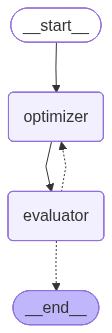

In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict
from IPython.display import Image, display

# Define the state
class State(TypedDict):
    text: str
    summary: str
    feedback: str
    attempts: int

# Optimizer node - generates/updates summary
def optimizer(state: State) -> State:
    if state["attempts"] == 0:
        # First draft
        summary = f"Draft Summary: {state['text'][:50]}..."
    else:
        # Refined version with feedback applied
        summary = f"Refined Summary after feedback: {state['feedback']}"
    
    return {
        "summary": summary,
        "attempts": state["attempts"] + 1,
    }

# Evaluator node - checks summary quality
def evaluator(state: State) -> State:
    summary = state["summary"]
    feedback = ""

    # Simple evaluation rule (in real case use LLM or metrics)
    if len(summary.split()) < 8:
        feedback = "Too short. Please expand with more details."
    elif "Refined" not in summary and state["attempts"] < 2:
        feedback = "Needs refinement for clarity."
    else:
        feedback = "Looks good!"

    return {"feedback": feedback}

# Router: Decide next step
def router(state: State):
    if state["feedback"] == "Looks good!" or state["attempts"] >= 3:
        return END
    else:
        return "optimizer"

# Build graph
workflow = StateGraph(State)

workflow.add_node("optimizer", optimizer)
workflow.add_node("evaluator", evaluator)

workflow.set_entry_point("optimizer")
workflow.add_edge("optimizer", "evaluator")
workflow.add_conditional_edges("evaluator", router, {"optimizer": "optimizer", END: END})

graph = workflow.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
# Run it
final_state = graph.invoke({"text": "LangGraph helps in orchestrating LLM workflows.", "summary": "", "feedback": "", "attempts": 0})

print("Final State:", final_state)

Final State: {'text': 'LangGraph helps in orchestrating LLM workflows.', 'summary': 'Refined Summary after feedback: Needs refinement for clarity.', 'feedback': 'Looks good!', 'attempts': 2}


🔹 How it Works

Optimizer → creates a draft summary.

Evaluator → checks length and clarity, provides feedback.

Router → if good, stop. If not, go back to optimizer with feedback.

This loop continues until output is acceptable or retries hit the max.

🔹 Why it’s Useful?

Helps build self-correcting AI workflows.

Can implement automated grading, QA, hallucination reduction.

Mimics human processes of drafting + review.

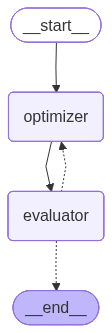

In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from IPython.display import Image, display
load_dotenv()

# Define the state
class State(TypedDict):
    text: str
    summary: str
    feedback: str
    attempts: int

# Initialize LLMs
optimizer_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Optimizer Node: Generates or refines the summary
def optimizer(state: State) -> State:
    if state["attempts"] == 0:
        prompt = f"Summarize the following text in 3-4 sentences:\n\n{state['text']}"
    else:
        prompt = f"Revise this summary based on feedback:\n\nSummary: {state['summary']}\nFeedback: {state['feedback']}"
    
    response = optimizer_llm.invoke(prompt)
    return {
        "summary": response.content,
        "attempts": state["attempts"] + 1,
    }

# Evaluator Node: Judges quality of the summary
def evaluator(state: State) -> State:
    prompt = f"""
    Review the following summary for clarity, completeness, and conciseness.
    Provide feedback. If it is good enough, simply respond with 'Looks good!'.

    Summary: {state['summary']}
    """
    response = evaluator_llm.invoke(prompt)
    return {"feedback": response.content.strip()}

# Router Node: Decides whether to stop or retry
def router(state: State):
    if "Looks good!" in state["feedback"] or state["attempts"] >= 3:
        return END
    else:
        return "optimizer"

# Build LangGraph Workflow
workflow = StateGraph(State)

workflow.add_node("optimizer", optimizer)
workflow.add_node("evaluator", evaluator)

workflow.set_entry_point("optimizer")
workflow.add_edge("optimizer", "evaluator")
workflow.add_conditional_edges("evaluator", router, {"optimizer": "optimizer", END: END})

graph = workflow.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
# Run Example
final_state = graph.invoke({
    "text": "LangGraph is a framework for building stateful, controllable LLM workflows. "
            "It enables orchestrating agents, memory, and tools with advanced patterns "
            "like parallelism, conditional routing, and evaluator-optimizer loops.",
    "summary": "",
    "feedback": "",
    "attempts": 0
})

print("🔹 Final State:")
print(final_state)

🔹 Final State:
{'text': 'LangGraph is a framework for building stateful, controllable LLM workflows. It enables orchestrating agents, memory, and tools with advanced patterns like parallelism, conditional routing, and evaluator-optimizer loops.', 'summary': 'LangGraph is a framework designed for creating stateful and controllable workflows for large language models (LLMs). It allows users to orchestrate various components, including agents, memory, and tools, while supporting advanced features like parallelism, conditional routing, and evaluator-optimizer loops. This enables more sophisticated interactions and improved efficiency in LLM applications.', 'feedback': 'Looks good!', 'attempts': 1}
